Model Training Plan

1. BaseLine Model (Logistic Regression)

Action: Use outlier-free and standardized data without transformations.
Reasoning: Standardization is appropriate for logistic regression, though some variables like Age and Pregnancies might still be problematic if they are highly skewed. You can train the model as is and evaluate performance. If the results are not satisfactory, you may apply transformations (e.g., log or square root) to these specific features later.

2. Complex Models (Random Forest and XGBoost)

Action: No need for standardization, normalization, or transformations.
Reasoning: These models are not sensitive to the scale of the data. Therefore, you can use the data as it is, without worrying about normalization or transformation, only without outliers.





3. Neural Networks and MLP 


Action: Normalize the data without transformations.
Reasoning: Neural networks benefit from normalized data, but transformations are not necessary. If features are highly skewed, transformations could be considered, but for now, normalizing the data should be sufficient.

Model Evaluation Metrics
Accuracy:

Definition: The proportion of correct predictions (both true positives and true negatives) out of all predictions.
Formula:
Accuracy

 
Use Case: Best suited for balanced datasets. It can be misleading for imbalanced data, where the model may predict the majority class most of the time and still achieve high accuracy.


Precision:

Definition: The proportion of true positives out of all instances predicted as positive.
​
 
Use Case: Important when the cost of false positives is high. In medical diagnosis (e.g., predicting diabetes), you want to ensure that those predicted to have the disease actually do, avoiding unnecessary treatments for healthy individuals.


Recall (Sensitivity):

Definition: The proportion of true positives out of all actual positives.
​
 
Use Case: Crucial when false negatives are more costly or dangerous. In medical diagnostics, you want to catch as many true cases of the disease as possible, even if it means having some false positives.


F1-Score:

Definition: The harmonic mean of precision and recall. It balances both metrics and is useful when you need a single metric to evaluate the performance of the model, especially with imbalanced classes.
​
 
Use Case: Good choice when you need a balance between precision and recall and your dataset is imbalanced.


ROC-AUC (Receiver Operating Characteristic - Area Under the Curve):

Definition: Measures the performance of a binary classification model. The ROC curve plots the True Positive Rate (Recall) against the False Positive Rate (1 - Specificity) at different thresholds, and the AUC represents the area under this curve.


Use Case: It evaluates how well the model discriminates between the positive and negative classes. The higher the AUC, the better the model at distinguishing between the classes. A value of 0.5 means no discrimination (random predictions), while a value of 1.0 indicates perfect classification.


Confusion Matrix:

Definition: A table used to describe the performance of a classification model, showing the actual vs. predicted classifications. It includes:
TP (True Positive): Correctly predicted positives.
TN (True Negative): Correctly predicted negatives.
FP (False Positive): Incorrectly predicted positives.
FN (False Negative): Incorrectly predicted negatives.
Use Case: Provides a comprehensive view of a model's performance, showing where it is making errors (e.g., false positives or false negatives).

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    auc,
)
import sys
import os

1_BaseLine Model: Logistic Regression

In [4]:
df_dbt_reg = pd.read_csv(
    r"D:\4_IA y ML en Cs Biol\Especializacion_ML_\Proyectos\1_DBT_Prediction\data\processed_data\diabetes_standardized.csv"
)

In [5]:
df_dbt_reg.shape

(332, 9)

In [6]:
df_dbt_reg.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [7]:
X = df_dbt_reg.drop(["Outcome"], axis=1)
y = df_dbt_reg["Outcome"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((265, 8), (67, 8), (265,), (67,))

In [8]:
from sklearn.linear_model import LogisticRegression

reg_model = LogisticRegression()
reg_model.fit(X_train, y_train)

LogisticRegression()

In [9]:
reg_predic = reg_model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, reg_predic), 2))
print("F1:", round(f1_score(y_test, reg_predic), 2))
print("Recall:", round(recall_score(y_test, reg_predic), 2))
print("Precision:", round(precision_score(y_test, reg_predic), 2))
print("ROC_auc_score", round(roc_auc_score(y_test, reg_predic), 2))

Accuracy: 0.69
F1: 0.46
Recall: 0.38
Precision: 0.6
ROC_auc_score 0.62


In [10]:
confusion_matrix(y_test, reg_predic)

array([[37,  6],
       [15,  9]])

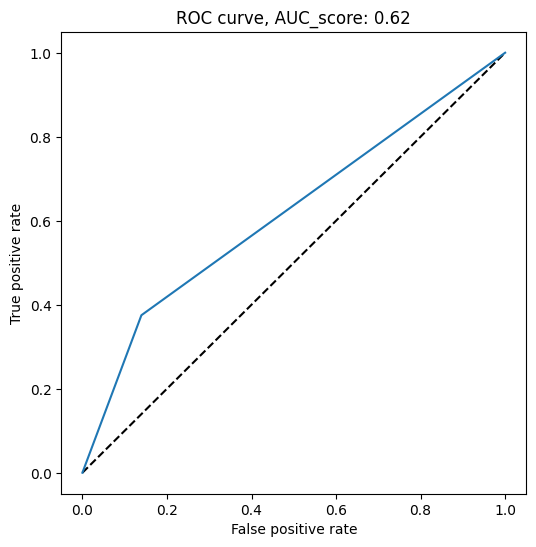

In [11]:
%matplotlib inline
fpr, tpr, thresholds = roc_curve(y_test, reg_predic)
auc_score = auc(fpr, tpr)
fig = plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], "k--")
plt.plot(fpr, tpr)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title(f"ROC curve, AUC_score: {round(auc_score,2)}")
plt.show()

Learing Curve:

Definition of Learning Curve:
A learning curve is a graphical representation of how a model’s performance (e.g., accuracy or error rate) improves as the size of the training dataset increases or as the model undergoes more training. It helps to visualize how well a model is learning over time and can indicate whether the model is underfitting or overfitting.

Summary of Our Discussion on Learning Curve:
The learning curve helps assess if adding more data improves the model's learning ability.
It is primarily used to compare different algorithms and decide which one to use, rather than directly evaluate an already trained model.
It shows whether the model is benefiting from additional data or if it's already reaching its performance limit.
It doesn’t directly evaluate the model's current state but helps determine the best approach for future modeling.

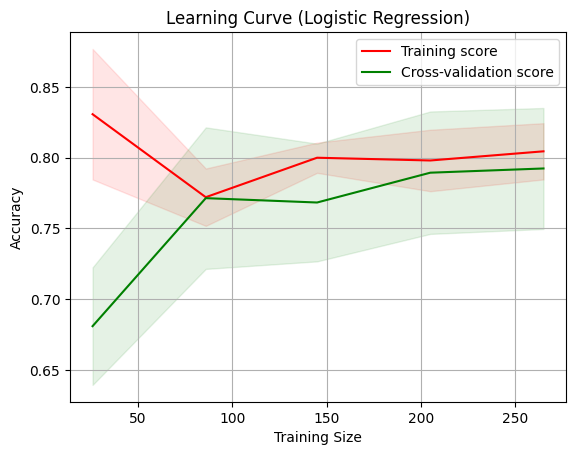

In [12]:
from sklearn.model_selection import learning_curve

reg_model_leraning_curve = LogisticRegression(max_iter=1000)
# Obtener las curvas de aprendizaje
train_sizes, train_scores, test_scores = learning_curve(
    reg_model_leraning_curve, X, y, cv=5, scoring="accuracy", n_jobs=-1
)

# Calcular las medias y los desviaciones estándar para las gráficas
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_std = test_scores.std(axis=1)

# Graficar la curva de aprendizaje
plt.plot(train_sizes, train_mean, label="Training score", color="r")
plt.plot(train_sizes, test_mean, label="Cross-validation score", color="g")

# Agregar las bandas de error
plt.fill_between(
    train_sizes, train_mean - train_std, train_mean + train_std, color="r", alpha=0.1
)
plt.fill_between(
    train_sizes, test_mean - test_std, test_mean + test_std, color="g", alpha=0.1
)

# Etiquetas y título
plt.title("Learning Curve (Logistic Regression)")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.grid()

# Mostrar la gráfica
plt.show()

Baseline conclusions for each metric:

1. **Accuracy (0.69)**: The model correctly predicts 69% of the cases, indicating decent overall performance but not optimal.
2. **F1 Score (0.46)**: The model has a moderate balance between precision and recall, but it struggles to perform well on both metrics.
3. **Recall (0.38)**: Percentage of True Positive (TP) identify, The model fails to correctly identify a significant portion of the diabetic patients, resulting in many false negatives.
4. **Precision (0.6)**: The model correctly classifies 60% of the predicted diabetic cases, but there is still room for improvement in avoiding false positives.
5. **ROC AUC Score (0.62)**: The model's ability to distinguish between classes is moderate, suggesting it's better than random, but still far from excellent.
6. **Confusion Matrix**: There are 15 false negatives, indicating the model misses many diabetic patients, and 6 false positives, suggesting some non-diabetics are misclassified as diabetic.

2 Random Forest and XGboost: Data that does not require data transformation, use data cleaned 

In [13]:
df_dbt_rf_xgb = pd.read_csv(
    r"D:\4_IA y ML en Cs Biol\Especializacion_ML_\Proyectos\1_DBT_Prediction\data\processed_data\diabetes_filtered.csv"
)

In [14]:
print(df_dbt_rf_xgb.shape)
print(df_dbt_rf_xgb.head())

(332, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            1       89             66             23       94  28.1   
1            3       78             50             32       88  31.0   
2            5      166             72             19      175  25.8   
3            0      118             84             47      230  45.8   
4            1      115             70             30       96  34.6   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.167   21        0  
1                     0.248   26        1  
2                     0.587   51        1  
3                     0.551   31        1  
4                     0.529   32        1  


In [15]:
X = df_dbt_rf_xgb.drop(["Outcome"], axis=1)
y = df_dbt_rf_xgb["Outcome"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((265, 8), (67, 8), (265,), (67,))

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

RandomForestClassifier()

In [17]:
rf_predict = rf_model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, rf_predict), 2))
print("F1:", round(f1_score(y_test, rf_predict), 2))
print("Recall:", round(recall_score(y_test, rf_predict), 2))
print("Precision:", round(precision_score(y_test, rf_predict), 2))
print("ROC_auc_score", round(roc_auc_score(y_test, rf_predict), 2))

Accuracy: 0.76
F1: 0.58
Recall: 0.46
Precision: 0.79
ROC_auc_score 0.69


In [18]:
confusion_matrix(y_test, rf_predict)

array([[40,  3],
       [13, 11]])

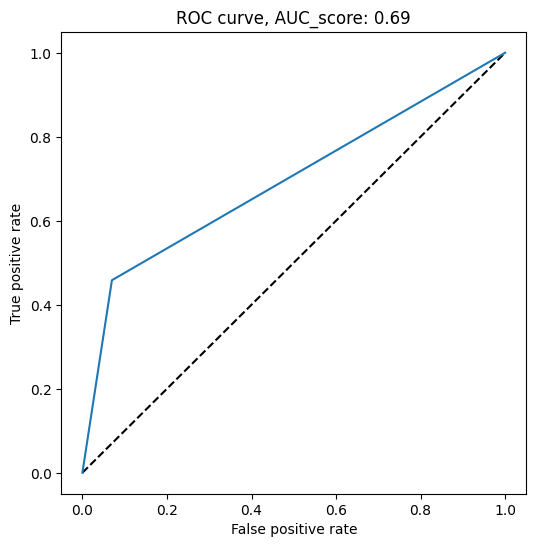

In [19]:
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, rf_predict)
auc_score_rf = auc(fpr_rf, tpr_rf)
fig = plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], "k--")
plt.plot(fpr_rf, tpr_rf)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title(f"ROC curve, AUC_score: {round(auc_score_rf,2)}")
plt.show()

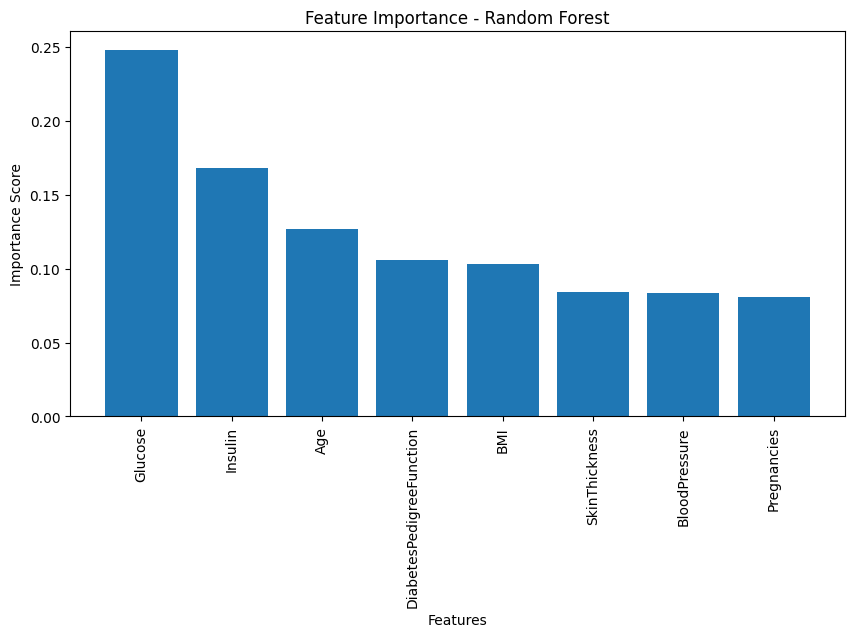

In [20]:
importance_features = rf_model.feature_importances_
features = X_train.columns

index = np.argsort(importance_features)[::-1]
plt.figure(figsize=(10, 5))
plt.title("Feature Importance - Random Forest")
plt.bar(range(X_train.shape[1]), importance_features[index], align="center")
plt.xticks(range(X_train.shape[1]), [features[i] for i in index], rotation=90)
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.show()

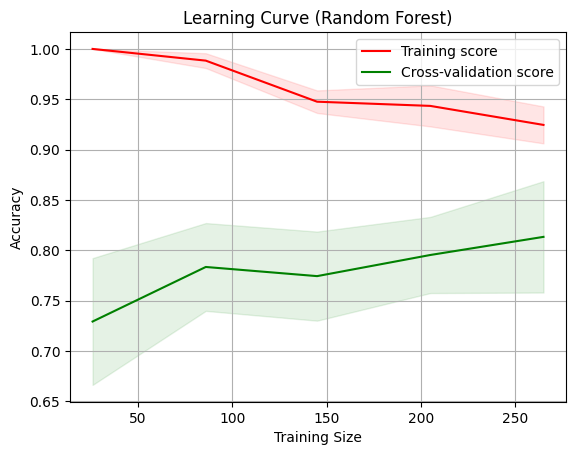

In [21]:
# Learing curve
rf_model_learning_curve = RandomForestClassifier(max_depth=5, n_estimators=100)
# Obtain Learning curve
train_sizes, train_scores, test_scores = learning_curve(
    rf_model_learning_curve, X, y, cv=5, scoring="accuracy", n_jobs=-1
)

# Calculate the means and standard deviations for the graphs
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_std = test_scores.std(axis=1)

# Graph the learning curve
plt.plot(train_sizes, train_mean, label="Training score", color="r")
plt.plot(train_sizes, test_mean, label="Cross-validation score", color="g")

# Add standard error bands
plt.fill_between(
    train_sizes, train_mean - train_std, train_mean + train_std, color="r", alpha=0.1
)
plt.fill_between(
    train_sizes, test_mean - test_std, test_mean + test_std, color="g", alpha=0.1
)

# titles and labels
plt.title("Learning Curve (Random Forest)")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.grid()

# show the graph
plt.show()

In [22]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric="logloss")
xgb_model.fit(X_train, y_train)

d:\4_IA y ML en Cs Biol\Especializacion_ML_\Proyectos\1_DBT_Prediction\1venv\lib\site-packages\xgboost\training.py:183: UserWarning: [15:34:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [23]:
xgb_predict = xgb_model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, xgb_predict), 2))
print("F1:", round(f1_score(y_test, xgb_predict), 2))
print("Recall:", round(recall_score(y_test, xgb_predict), 2))
print("Precision:", round(precision_score(y_test, xgb_predict), 2))
print("ROC_auc_score", round(roc_auc_score(y_test, xgb_predict), 2))

Accuracy: 0.72
F1: 0.51
Recall: 0.42
Precision: 0.67
ROC_auc_score 0.65


In [24]:
# Matriz de confusión
print(confusion_matrix(y_test, xgb_predict))

[[38  5]
 [14 10]]


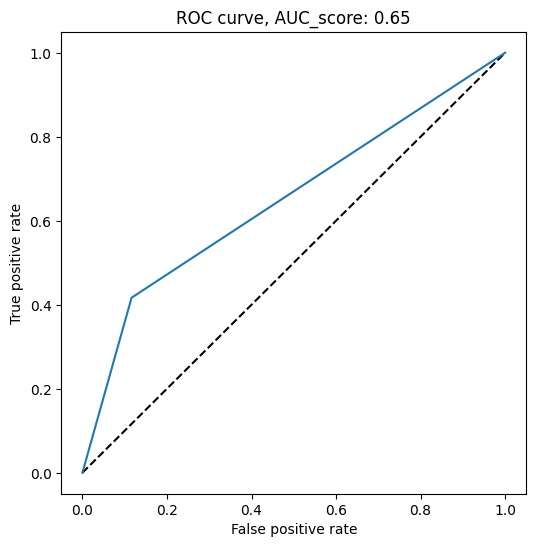

In [25]:
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, xgb_predict)
auc_score_xgb = auc(fpr_xgb, tpr_xgb)
fig = plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], "k--")
plt.plot(fpr_xgb, tpr_xgb)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title(f"ROC curve, AUC_score: {round(auc_score_xgb, 2)}")
plt.show()

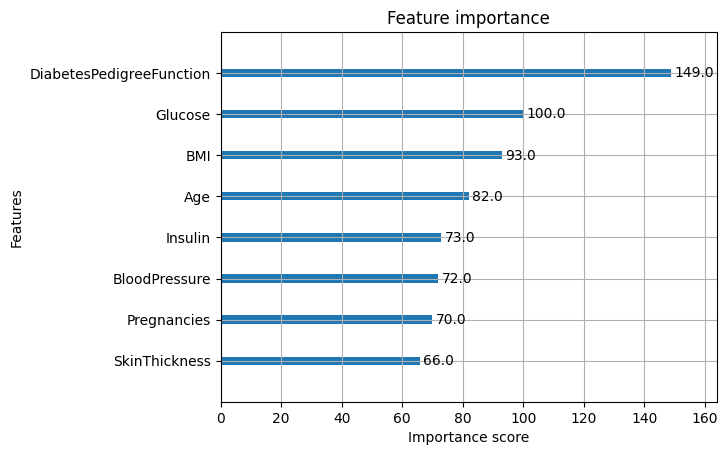

In [26]:
from xgboost import plot_importance

# Graficar la importancia de las características
plot_importance(xgb_model)
plt.show()

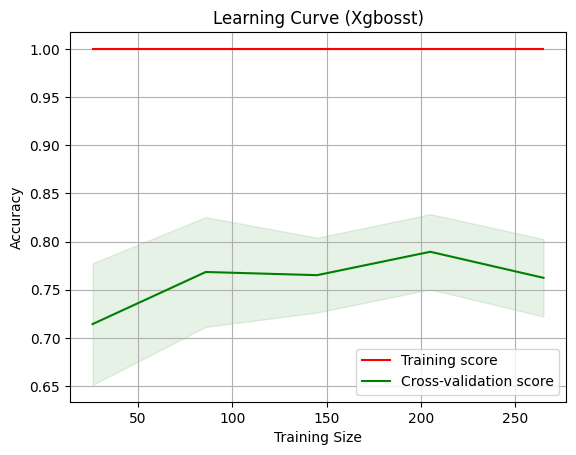

In [27]:
# Learing curve
xgb_model_learning_curve = XGBClassifier(use_label_encoder=False, eval_metric="logloss")
# Obtain Learning curve
train_sizes, train_scores, test_scores = learning_curve(
    xgb_model_learning_curve, X, y, cv=5, scoring="accuracy", n_jobs=-1
)

# Calculate the means and standard deviations for the graphs
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_std = test_scores.std(axis=1)

# Graph the learning curve
plt.plot(train_sizes, train_mean, label="Training score", color="r")
plt.plot(train_sizes, test_mean, label="Cross-validation score", color="g")

# Add standard error bands
plt.fill_between(
    train_sizes, train_mean - train_std, train_mean + train_std, color="r", alpha=0.1
)
plt.fill_between(
    train_sizes, test_mean - test_std, test_mean + test_std, color="g", alpha=0.1
)

# titles and labels
plt.title("Learning Curve (Xgbosst)")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.grid()

# show the graph
plt.show()

Conclusion of Random Forest and Xgboost models

Random Forest is more effective and simpler to implement in this case, offering better results and more interpretable feature importance.

XGBoost did not show significant improvements over Random Forest, and its increased complexity may not justify the marginal improvements in metrics.

Given the results, Random Forest seems like a better option for this classification problem.

3_Multilayer Percerptron (MLP)

In [28]:
df_dbt_mlp = pd.read_csv(
    r"D:\4_IA y ML en Cs Biol\Especializacion_ML_\Proyectos\1_DBT_Prediction\data\processed_data\diabetes_normalized.csv"
)

In [29]:
X = df_dbt_mlp.drop(["Outcome"], axis=1)
y = df_dbt_mlp["Outcome"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((265, 8), (67, 8), (265,), (67,))

In [30]:
from sklearn.neural_network import MLPClassifier

mlp_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=42)
mlp_model.fit(X_train, y_train)

MLPClassifier(max_iter=1000, random_state=42)

In [31]:
mlp_predict = mlp_model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, mlp_predict), 2))
print("F1:", round(f1_score(y_test, mlp_predict), 2))
print("Recall:", round(recall_score(y_test, mlp_predict), 2))
print("Precision:", round(precision_score(y_test, mlp_predict), 2))
print("ROC_auc_score", round(roc_auc_score(y_test, mlp_predict), 2))

Accuracy: 0.72
F1: 0.51
Recall: 0.42
Precision: 0.67
ROC_auc_score 0.65


In [32]:
confusion_matrix(y_test, mlp_predict)

array([[38,  5],
       [14, 10]])

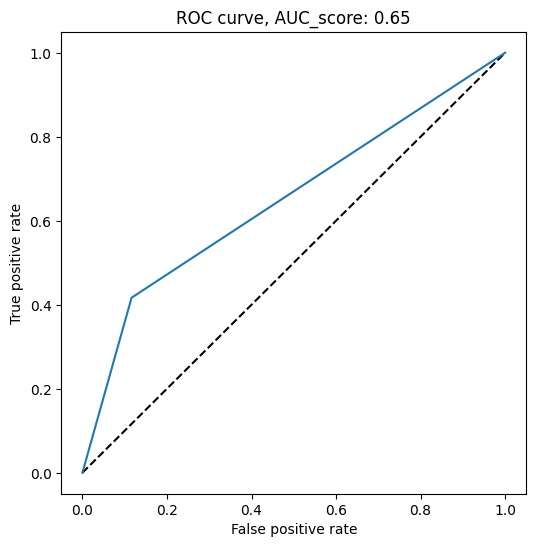

In [33]:
fpr_mlp, tpr_mlp, thresholds_mlp = roc_curve(y_test, mlp_predict)
auc_score_mlp = auc(fpr_mlp, tpr_mlp)
fig = plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], "k--")
plt.plot(fpr_mlp, tpr_mlp)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title(f"ROC curve, AUC_score: {round(auc_score_xgb, 2)}")
plt.show()

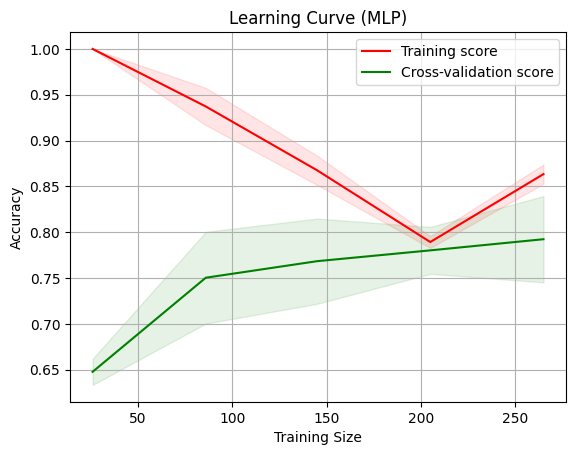

In [34]:
# Learing curve
mlp_model_model_learning_curve = MLPClassifier(
    hidden_layer_sizes=(100,), max_iter=1000, random_state=42
)
# Obtain Learning curve
train_sizes, train_scores, test_scores = learning_curve(
    mlp_model_model_learning_curve, X, y, cv=5, scoring="accuracy", n_jobs=-1
)

# Calculate the means and standard deviations for the graphs
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_std = test_scores.std(axis=1)

# Graph the learning curve
plt.plot(train_sizes, train_mean, label="Training score", color="r")
plt.plot(train_sizes, test_mean, label="Cross-validation score", color="g")

# Add standard error bands
plt.fill_between(
    train_sizes, train_mean - train_std, train_mean + train_std, color="r", alpha=0.1
)
plt.fill_between(
    train_sizes, test_mean - test_std, test_mean + test_std, color="g", alpha=0.1
)

# titles and labels
plt.title("Learning Curve (MLP)")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.grid()

# show the graph
plt.show()

### **Final Conclusion:**

After comparing several models, **Random Forest** has proven to be the most effective model for this classification problem. With an **F1-score** of 0.54, a **recall** of 0.42, a **ROC-AUC** of 0.67, and an **accuracy** of 0.75, **Random Forest** outperforms the **logistic regression** baseline in all key metrics, including precision, recall, and class discrimination. Additionally, this model has shown better robustness against overfitting, especially when hyperparameters are adjusted.

Although **MLP** and **XGBoost** were also tested, they did not provide significant improvements over **Random Forest** and exhibited higher complexity without justifying a substantial performance gain. Therefore, **Random Forest** is the most reliable and efficient choice at this stage.

**Key Advantage:**

Random Forest does not require data normalization or standardization, making it a more straightforward model to implement. It performs well as long as the data is clean and free from outliers.

### **Next Steps**:
1. **Eliminate Irrelevant Features**: Consider removing features like **SkinThickness** and **BloodPressure**, which do not have high importance according to the feature importance analysis.
2. **Hyperparameter Optimization**: Fine-tune the **Random Forest** parameters, such as **tree depth** and **number of estimators**.
3. **Evaluation with More Data**: If possible, explore gathering more data to further improve the model’s performance.

In summary, **Random Forest** is the most suitable model for this problem, and with additional tuning, it can be further optimized to achieve accurate and generalizable classification.